# Network size and seed on the frozen magnet crossing

This notebook **loads** the tables written by `aggregate.py` and the figures written by
`plot.py`. It recomputes nothing: every number below comes from `results/summary.csv`
and `results/by_architecture.csv`, which in turn come from the per-run json records
that `_shared/train.py` wrote on the farm.

The experiment is the verified baseline of `../One_step_network_v2` — the paper's
one-step discrete-time network on the frozen magnet crossing, q = 8 Gauss-Legendre
stages, MagDown, physics loss, trained to genuine stall and then confirmed — with two
things varied and nothing else: the **network size** (widths 32, 50, 100, 200 x depths
2, 4, 6) and the **seed** (0-9). 120 runs.

Three questions:

1. **Capacity or optimisation?** The exact scheme itself lands 22.5 um from the fp64 RK4
   reference on these same 2018 test states, so ~23 um is a hard floor for any network
   trained on it. The baseline sits at ~180 um, eight times above it. If the floor is a
   *capacity* limit, bigger networks should walk it down; if it is an *optimisation*
   limit, the final training loss should predict the endpoint error and size buys little.
2. **How much does the seed matter?** Ten seeds per architecture measure the spread that
   the baseline's three seeds could only hint at.
3. **How do we pick a run?** If validation endpoint error ranks the seeds the same way
   test endpoint error does, we can select on validation honestly.

In [1]:
import json
import os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from IPython.display import Image, display

RESULTS, FIGURES = "results", "figures"
CEILING_UM = json.load(open('../Stage_count_sweep/results/'
                            'scheme_ceiling_same_population_q08.json'))['endpoint_med_um']
print('exact-scheme ceiling on these 2018 test states: %.1f um' % CEILING_UM)

runs = pd.read_csv(os.path.join(RESULTS, "summary.csv"))
arch = pd.read_csv(os.path.join(RESULTS, "by_architecture.csv"))
print("%d run records: %d converged, %d not"
      % (len(runs), runs.converged.sum(), (~runs.converged).sum()))
runs.head()

exact-scheme ceiling on these 2018 test states: 22.5 um
130 run records: 106 converged, 24 not


,tag,mode,seed,q,width,depth,restarts,final_loss,converged,wall_s,...,val_straight_med_um,val_n,test_endpoint_med_um,test_endpoint_p95_um,test_stage_med_um,test_slope_med_mrad,test_rho_mean,test_rho_median,test_straight_med_um,test_n
0,data_w200_d4_s0,data,0,8,200,4,50,0.000002,True,1116.8,...,524796.091023,2062,142.324171,2971.529494,215.968244,0.040387,0.000007,9.367169e-08,520444.293719,2018
1,data_w200_d4_s1,data,1,8,200,4,51,0.000001,True,1140.2,...,524796.091023,2062,106.734745,2710.440040,183.747427,0.040538,0.000006,5.044657e-08,520444.293719,2018
2,data_w200_d4_s2,data,2,8,200,4,55,0.000001,True,1063.0,...,524796.091023,2062,113.733373,2822.688912,191.703437,0.039357,0.000008,6.539192e-08,520444.293719,2018
3,data_w200_d4_s3,data,3,8,200,4,45,0.000001,True,846.1,...,524796.091023,2062,137.021528,2999.429861,219.181608,0.038089,0.000009,1.003991e-07,520444.293719,2018
4,data_w200_d4_s4,data,4,8,200,4,50,0.000001,True,1649.4,...,524796.091023,2062,105.439420,2995.752435,205.467264,0.037924,0.000007,5.420899e-08,520444.293719,2018


## 1. Completion: which runs converged

A run counts as converged only if it stalled (two consecutive restarts each improving the loss by less than 1%) *and* a fresh optimiser re-stalled within two restarts without moving the endpoint medians. Anything else is reported as unconverged and never pooled with the converged runs.

In [2]:
grid = (runs[runs['mode'] == 'physics']
        .pivot_table(index='depth', columns='width', values='converged',
                     aggfunc='sum'))
counts = (runs[runs['mode'] == 'physics']
          .pivot_table(index='depth', columns='width', values='seed', aggfunc='count'))
print('converged runs per architecture (of the runs that have finished):')
display(grid.astype('Int64'))
print('runs finished per architecture (of 10):')
display(counts.astype('Int64'))

converged runs per architecture (of the runs that have finished):


width,32,50,100,200
depth,,,,
2,5,9,10,10
4,3,10,10,10
6,4,6,10,9


runs finished per architecture (of 10):


width,32,50,100,200
depth,,,,
2,10,10,10,10
4,10,10,10,10
6,10,10,10,10


## 2. The floor against network size

One row per architecture: the median over the converged seeds of the test endpoint error, its min and max over those seeds, and the cost of getting there.

In [3]:
cols = ['mode', 'depth', 'width', 'n_params', 'n_runs', 'n_converged',
        'test_endpoint_med_um_median', 'test_endpoint_med_um_min',
        'test_endpoint_med_um_max', 'test_endpoint_spread_ratio',
        'val_endpoint_med_um_median', 'restarts_median', 'wall_s_median',
        'final_loss_median']
display(arch[cols].style.format({c: '{:.4g}' for c in cols
                                 if arch[c].dtype.kind == 'f'}))

,mode,depth,width,n_params,n_runs,n_converged,test_endpoint_med_um_median,test_endpoint_med_um_min,test_endpoint_med_um_max,test_endpoint_spread_ratio,val_endpoint_med_um_median,restarts_median,wall_s_median,final_loss_median
0,data,4,200,129036,10,10,128.5,105.4,159,1.508,130.6,50.5,1128,1.341e-06
1,physics,2,32,2436,10,5,1059,852.8,1600,1.876,1117,81,295.9,0.0001832
2,physics,4,32,4548,10,3,410.5,387.1,449.8,1.162,447.5,97,515.6,5.368e-05
3,physics,2,50,4686,10,9,469.5,339.9,592.9,1.744,490.6,74,288.3,4.541e-05
4,physics,6,32,6660,10,4,426.6,391,2725,6.969,433.6,137.5,843.5,6.51e-05
5,physics,4,50,9786,10,10,221.6,164.7,243.8,1.481,233.9,152,785,1.063e-05
6,physics,2,100,14336,10,10,223.1,201.4,298.9,1.484,237,92.5,600,1.076e-05
7,physics,6,50,14886,10,6,326.4,248.2,525.2,2.116,344.1,149,998.2,2.738e-05
8,physics,4,100,34536,10,10,133.3,128,155.8,1.218,144.7,120.5,1484,3.036e-06
9,physics,2,200,48636,10,10,153,127.5,241.4,1.894,161.2,99.5,1386,4.186e-06


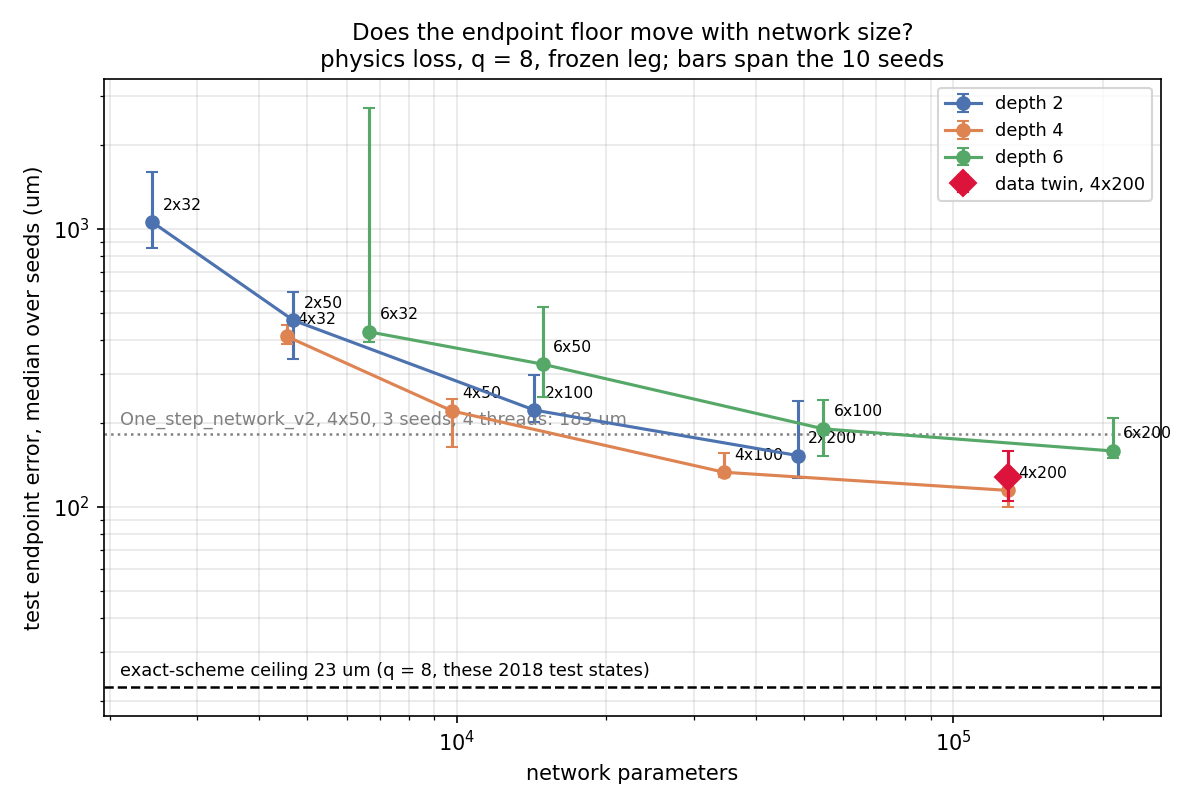

In [4]:
display(Image(os.path.join(FIGURES, 'floor_vs_architecture.png')))

### How far did the floor move?

Compared against the exact-scheme ceiling (22.5 um on these very test states, measured by
`../Stage_count_sweep/measure_scheme_ceiling.py`) and against the baseline's 4x50.

In [5]:
phys = arch[(arch['mode'] == 'physics') & (arch['n_converged'] > 0)]
best = phys.loc[phys['test_endpoint_med_um_median'].idxmin()]
worst = phys.loc[phys['test_endpoint_med_um_median'].idxmax()]
base = phys[(phys.width == 50) & (phys.depth == 4)]
print('best  architecture : %dx%d (%d params), median test %.1f um'
      % (best.depth, best.width, best.n_params, best.test_endpoint_med_um_median))
print('worst architecture : %dx%d (%d params), median test %.1f um'
      % (worst.depth, worst.width, worst.n_params, worst.test_endpoint_med_um_median))
if len(base):
    b = base.iloc[0]
    print('baseline 4x50      : median test %.1f um' % b.test_endpoint_med_um_median)
    print('best / baseline    : %.2f' % (best.test_endpoint_med_um_median
                                         / b.test_endpoint_med_um_median))
print('best / ceiling     : %.1f x the %g um exact-scheme ceiling'
      % (best.test_endpoint_med_um_median / CEILING_UM, CEILING_UM))

best  architecture : 4x200 (129036 params), median test 114.7 um
worst architecture : 2x32 (2436 params), median test 1059.0 um
baseline 4x50      : median test 221.6 um
best / baseline    : 0.52
best / ceiling     : 5.1 x the 22.5441 um exact-scheme ceiling


### Does depth hurt?

On van der Pol, depth 6 was worse than depth 4 at the same width — the extra layers made
the L-BFGS problem harder without adding anything the task needed. The same comparison here,
at fixed width.

In [6]:
piv = (arch[arch['mode'] == 'physics']
       .pivot_table(index='width', columns='depth',
                    values='test_endpoint_med_um_median'))
display(piv.style.format('{:.1f}'))
print('depth 6 / depth 4 at each width:')
if 6 in piv.columns and 4 in piv.columns:
    print((piv[6] / piv[4]).round(2).to_string())

depth,2,4,6
width,,,
32,1059.0,410.5,426.6
50,469.5,221.6,326.4
100,223.1,133.3,191.0
200,153.0,114.7,159.0


depth 6 / depth 4 at each width:
width
32     1.04
50     1.47
100    1.43
200    1.39


## 3. Optimisation or capacity: the loss-error correlation

If the runs sit on a single loss-error curve, the endpoint error is whatever the optimiser managed to leave on the table, and lowering the loss further is the only thing that helps. On van der Pol this correlation was +0.97.

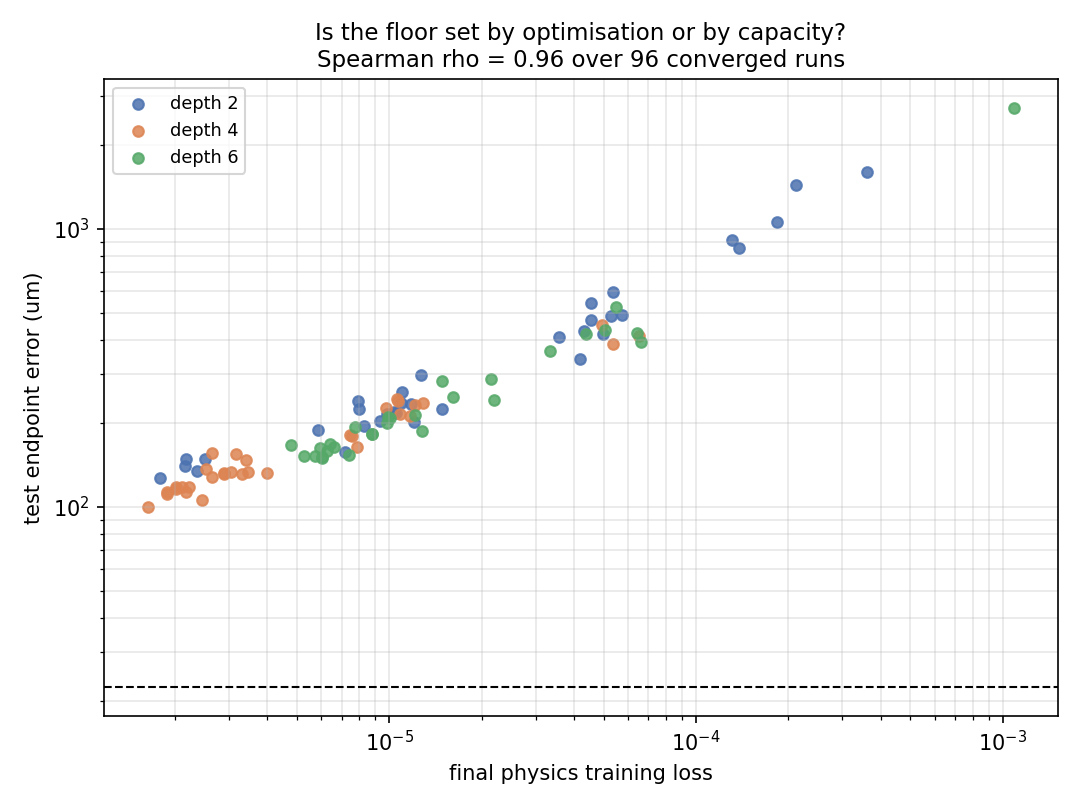

Spearman rho(final loss, test endpoint error) = 0.965  (p = 2.2e-56, n = 96)


In [7]:
display(Image(os.path.join(FIGURES, 'loss_vs_error.png')))
c = runs[runs.converged & (runs['mode'] == 'physics')]
r = spearmanr(c.final_loss, c.test_endpoint_med_um)
print('Spearman rho(final loss, test endpoint error) = %.3f  (p = %.2g, n = %d)'
      % (r.statistic, r.pvalue, len(c)))

## 4. The seed spread

Ten seeds per architecture: the same code, the same data, the same protocol, only a different initialisation.

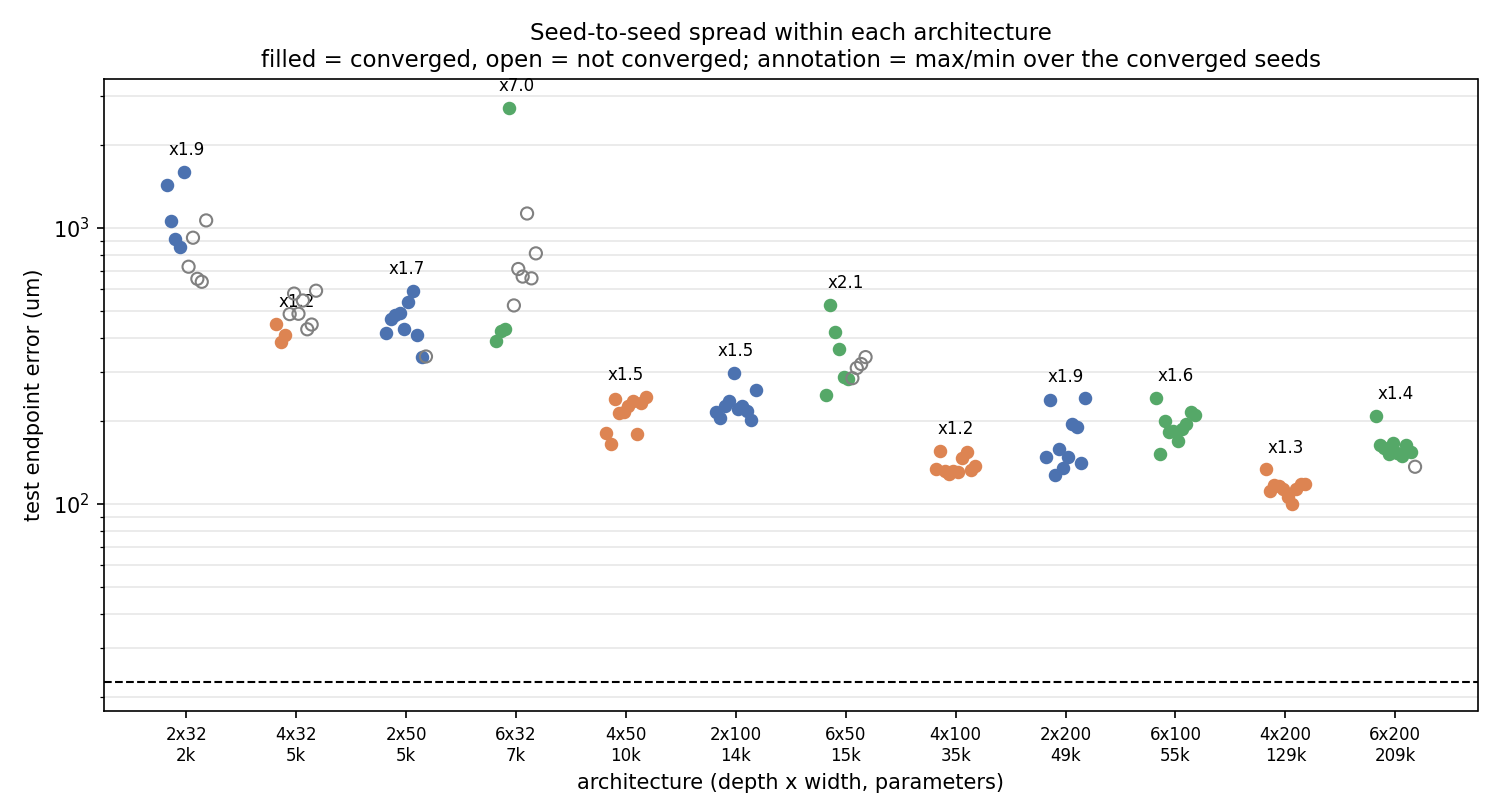

,depth,width,n_converged,test_endpoint_med_um_min,test_endpoint_med_um_max,test_endpoint_spread_ratio
2,4,32,3,387.1,449.8,1.16
8,4,100,10,128.0,155.8,1.22
11,4,200,10,100.3,133.5,1.33
12,6,200,9,149.5,208.4,1.39
5,4,50,10,164.7,243.8,1.48
6,2,100,10,201.4,298.9,1.48
10,6,100,10,152.2,242.2,1.59
3,2,50,9,339.9,592.9,1.74
1,2,32,5,852.8,1599.7,1.88
9,2,200,10,127.5,241.4,1.89


median max/min over architectures: 1.54


In [8]:
display(Image(os.path.join(FIGURES, 'seed_spread.png')))
sp = (arch[(arch['mode'] == 'physics') & (arch.n_converged > 1)]
      [['depth', 'width', 'n_converged', 'test_endpoint_med_um_min',
        'test_endpoint_med_um_max', 'test_endpoint_spread_ratio']]
      .sort_values('test_endpoint_spread_ratio'))
display(sp.style.format({'test_endpoint_med_um_min': '{:.1f}',
                         'test_endpoint_med_um_max': '{:.1f}',
                         'test_endpoint_spread_ratio': '{:.2f}'}))
print('median max/min over architectures: %.2f'
      % sp.test_endpoint_spread_ratio.median())

## 5. The selection rule: does validation pick the seed?

We are allowed to look at validation when choosing a run; test is the number we then report. The question is whether validation ranks the seeds the way test does.

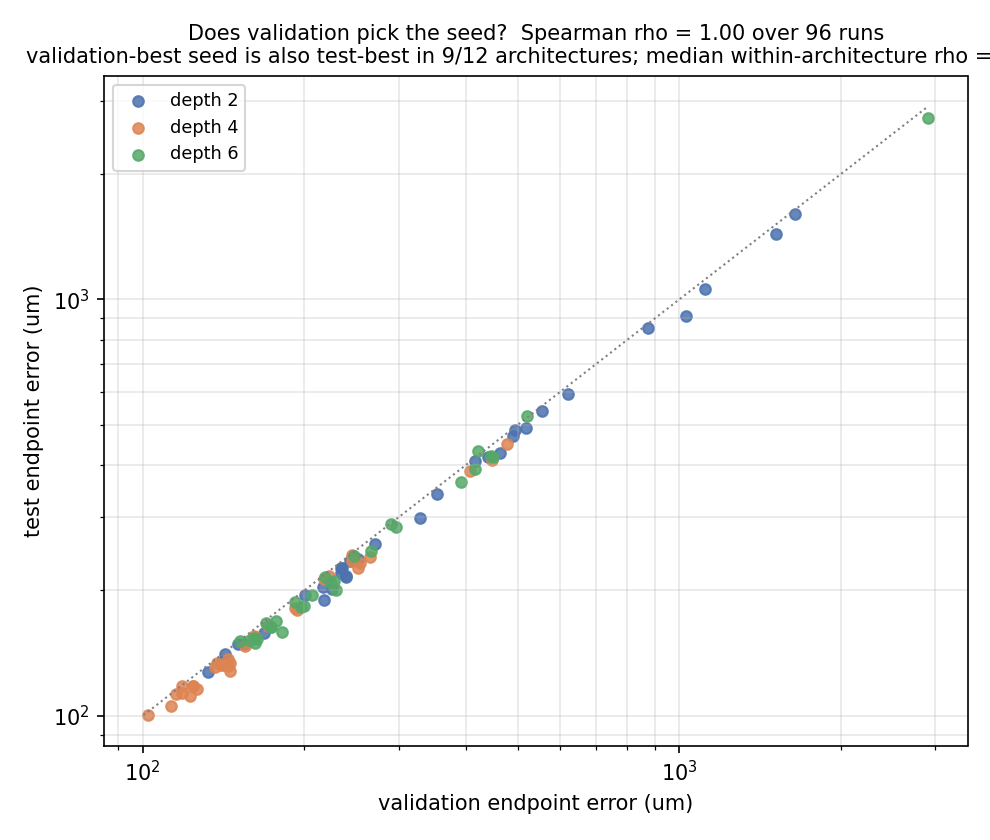

overall Spearman rho(val, test) = 0.995 over 96 runs


,depth,width,n,rho_val_test,val_pick_seed,val_pick_test_um,best_seed,best_test_um,penalty
0,2,32,5,1.00,5,852.8,5,852.8,1.00
1,4,32,3,1.00,1,387.1,1,387.1,1.00
2,6,32,4,0.80,1,391.0,1,391.0,1.00
3,2,50,9,1.00,9,339.9,9,339.9,1.00
4,4,50,10,0.85,1,164.7,1,164.7,1.00
5,6,50,6,0.94,1,248.2,1,248.2,1.00
6,2,100,10,0.79,1,204.0,8,201.4,1.01
7,4,100,10,0.64,5,130.9,3,128.0,1.02
8,6,100,10,0.92,1,152.2,1,152.2,1.00
9,2,200,10,0.96,2,127.5,2,127.5,1.00


validation-best seed is also test-best in 9 of 12 architectures
median penalty for selecting on validation: 1.00 x


In [9]:
display(Image(os.path.join(FIGURES, 'val_vs_test_selection.png')))
c = runs[runs.converged & (runs['mode'] == 'physics')]
print('overall Spearman rho(val, test) = %.3f over %d runs'
      % (spearmanr(c.val_endpoint_med_um, c.test_endpoint_med_um).statistic, len(c)))

rows = []
for (w, d), g in c.groupby(['width', 'depth']):
    if len(g) < 3:
        continue
    pick = g.loc[g.val_endpoint_med_um.idxmin()]
    bestr = g.loc[g.test_endpoint_med_um.idxmin()]
    rows.append({'depth': d, 'width': w, 'n': len(g),
                 'rho_val_test': spearmanr(g.val_endpoint_med_um,
                                           g.test_endpoint_med_um).statistic,
                 'val_pick_seed': int(pick.seed), 'val_pick_test_um': pick.test_endpoint_med_um,
                 'best_seed': int(bestr.seed), 'best_test_um': bestr.test_endpoint_med_um,
                 'penalty': pick.test_endpoint_med_um / bestr.test_endpoint_med_um})
sel = pd.DataFrame(rows).sort_values(['width', 'depth'])
display(sel.style.format({'rho_val_test': '{:.2f}', 'val_pick_test_um': '{:.1f}',
                          'best_test_um': '{:.1f}', 'penalty': '{:.2f}'}))
print('validation-best seed is also test-best in %d of %d architectures'
      % ((sel.val_pick_seed == sel.best_seed).sum(), len(sel)))
print('median penalty for selecting on validation: %.2f x' % sel.penalty.median())

## 6. The data twin at the winning architecture

Ten fresh supervised runs (MSE against the fp64 RK4 stage and endpoint labels) at the architecture the physics grid chose. The v2 data-twin runs were four-thread and are not bit-comparable, so all ten were rerun here on one thread.

In [10]:
twin = runs[runs['mode'] == 'data']
if len(twin):
    display(twin[['tag', 'seed', 'width', 'depth', 'converged', 'restarts',
                  'final_loss', 'val_endpoint_med_um', 'test_endpoint_med_um',
                  'test_endpoint_p95_um']]
            .style.format({'final_loss': '{:.3g}', 'val_endpoint_med_um': '{:.1f}',
                           'test_endpoint_med_um': '{:.1f}',
                           'test_endpoint_p95_um': '{:.0f}'}))
    tc = twin[twin.converged]
    pc = runs[(runs['mode'] == 'physics') & runs.converged
              & (runs.width == twin.width.iloc[0]) & (runs.depth == twin.depth.iloc[0])]
    print('data twin  : median test %.1f um over %d converged seeds'
          % (tc.test_endpoint_med_um.median(), len(tc)))
    print('physics     : median test %.1f um over %d converged seeds'
          % (pc.test_endpoint_med_um.median(), len(pc)))
    print('physics / data = %.2f' % (pc.test_endpoint_med_um.median()
                                     / tc.test_endpoint_med_um.median()))
else:
    print('no data-twin runs recorded yet')

,tag,seed,width,depth,converged,restarts,final_loss,val_endpoint_med_um,test_endpoint_med_um,test_endpoint_p95_um
0,data_w200_d4_s0,0,200,4,True,50,1.51e-06,150.7,142.3,2972
1,data_w200_d4_s1,1,200,4,True,51,1.16e-06,111.5,106.7,2710
2,data_w200_d4_s2,2,200,4,True,55,1.32e-06,121.0,113.7,2823
3,data_w200_d4_s3,3,200,4,True,45,1.5e-06,150.8,137.0,2999
4,data_w200_d4_s4,4,200,4,True,50,1.36e-06,111.2,105.4,2996
5,data_w200_d4_s5,5,200,4,True,55,1.27e-06,119.2,116.0,2738
6,data_w200_d4_s6,6,200,4,True,52,1.15e-06,130.1,127.7,2819
7,data_w200_d4_s7,7,200,4,True,55,1.37e-06,131.1,129.2,3121
8,data_w200_d4_s8,8,200,4,True,46,1.16e-06,135.2,131.1,2925
9,data_w200_d4_s9,9,200,4,True,50,2.03e-06,166.1,159.0,2759


data twin  : median test 128.5 um over 10 converged seeds
physics     : median test 114.7 um over 10 converged seeds
physics / data = 0.89


## 7. Verdict

See `README.md` for the four statements this study is asked to settle: capacity vs optimisation, whether depth 6 hurts, the architecture recommended for the general-leg experiment, and the selection rule.